# **Implementasi Data Warehouse dan OLAP untuk Analisis Pola Kriminalitas Berdasarkan Dimensi Waktu, Lokasi, dan Karakteristik Korban di India Periode 2020–2024**

# **PROJECT AKHIR DATA WAREHOUSE KELOMPOK 1**

Nama Anggota Kelompok:
1. Yanaka Sofia Pardede (24031554065)
2. Ayu Wulan Anggraeni Putri (24031554177)
3. Annisa Ramadhani (24031554206)

Kelas: 2024B

## **1. Import Library dan Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/Shareddrives/PROJECT DATA WAREHOUSE KEL 1/crime_dataset_india.csv')

## **2. Data Understanding**

In [ ]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


In [ ]:
df.columns.tolist()

['Report Number',
 'Date Reported',
 'Date of Occurrence',
 'Time of Occurrence',
 'City',
 'Crime Code',
 'Crime Description',
 'Victim Age',
 'Victim Gender',
 'Weapon Used',
 'Crime Domain',
 'Police Deployed',
 'Case Closed',
 'Date Case Closed']

In [ ]:
df.shape

(40160, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       40160 non-null  int64 
 1   Date Reported       40160 non-null  object
 2   Date of Occurrence  40160 non-null  object
 3   Time of Occurrence  40160 non-null  object
 4   City                40160 non-null  object
 5   Crime Code          40160 non-null  int64 
 6   Crime Description   40160 non-null  object
 7   Victim Age          40160 non-null  int64 
 8   Victim Gender       40160 non-null  object
 9   Weapon Used         34370 non-null  object
 10  Crime Domain        40160 non-null  object
 11  Police Deployed     40160 non-null  int64 
 12  Case Closed         40160 non-null  object
 13  Date Case Closed    20062 non-null  object
dtypes: int64(4), object(10)
memory usage: 4.3+ MB


## **3. Pemeriksaan Missing Value**

In [ ]:
df.isnull().sum()

,0
Report Number,0
Date Reported,0
Date of Occurrence,0
Time of Occurrence,0
City,0
Crime Code,0
Crime Description,0
Victim Age,0
Victim Gender,0
Weapon Used,5790


In [ ]:
missing_count = df.isnull().sum()

missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
})

missing_df = missing_df[missing_df["Missing Count"] > 0]

missing_df.sort_values("Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
Date Case Closed,20098,50.044821
Weapon Used,5790,14.417331


## **4. Analisis Statistik Deskriptif**

In [ ]:
df.describe()

,Report Number,Crime Code,Victim Age,Police Deployed
count,40160.000000,40160.000000,40160.00000,40160.000000
mean,20080.500000,349.360259,44.49126,10.006250
std,11593.337742,144.169205,20.22555,5.467951
min,1.000000,100.000000,10.00000,1.000000
25%,10040.750000,225.000000,27.00000,5.000000
50%,20080.500000,349.000000,44.00000,10.000000
75%,30120.250000,474.000000,62.00000,15.000000
max,40160.000000,599.000000,79.00000,19.000000


## **5. Pemeriksaan Data Duplikat**

In [ ]:
df.duplicated().sum()

np.int64(0)

## **6. Analisis Rentang Waktu Data**

In [ ]:
df['Date Reported'] = pd.to_datetime(
    df['Date Reported'],
    dayfirst=True
)

print(df['Date Reported'].min())
print(df['Date Reported'].max())

2020-01-01 05:00:00
2024-08-02 18:00:00


## **7. Exploratory Data Analysis (EDA)**

### **7.1 Distribusi Crime Domain**

In [ ]:
df['Crime Domain'].value_counts()

,count
Crime Domain,
Other Crime,22948
Violent Crime,11472
Fire Accident,3825
Traffic Fatality,1915


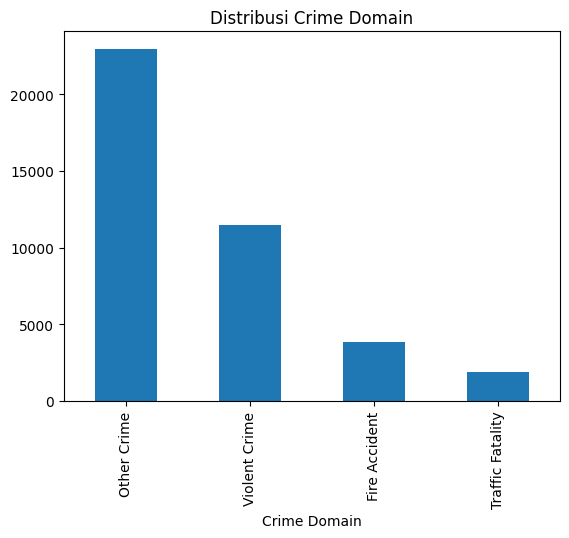

In [ ]:
import matplotlib.pyplot as plt

df['Crime Domain'].value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Crime Domain")
plt.show()

### **7.2 Distribusi Gender Korban**

In [ ]:
df['Victim Gender'].value_counts()

,count
Victim Gender,
F,22423
M,13405
X,4332


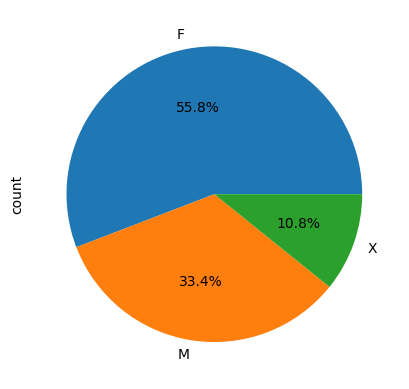

In [ ]:
df['Victim Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

### **7.3 Top 10 Kota dengan Jumlah Kasus Tertinggi**

In [ ]:
top_city = df['City'].value_counts().head(10)

top_city

,count
City,
Delhi,5400
Mumbai,4415
Bangalore,3588
Hyderabad,2881
Kolkata,2518
Chennai,2493
Pune,2212
Ahmedabad,1817
Jaipur,1479


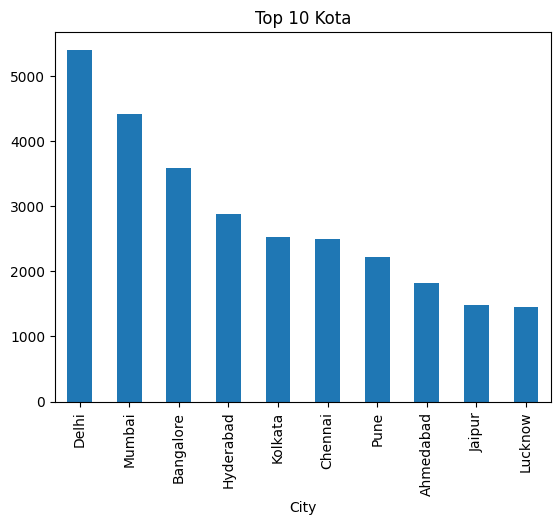

In [ ]:
top_city.plot(kind='bar')
plt.title("Top 10 Kota")
plt.show()

### **7.4 Distribusi Usia Korban**

<Axes: xlabel='Victim Age'>

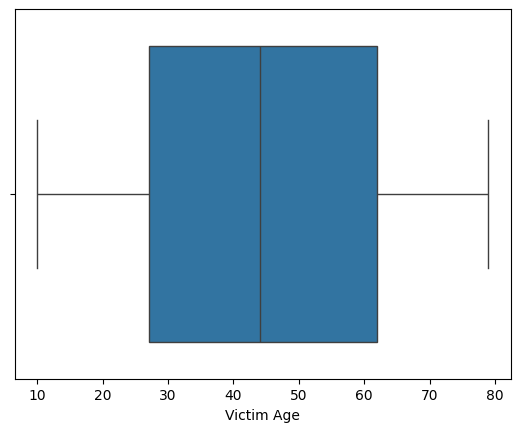

In [ ]:
import seaborn as sns

sns.boxplot(
    x=df['Victim Age']
)

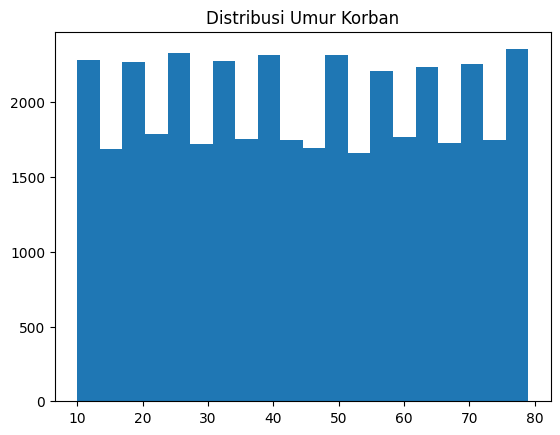

In [ ]:
plt.hist(
    df['Victim Age'],
    bins=20
)

plt.title("Distribusi Umur Korban")
plt.show()

### **7.5 Distribusi Status Penyelesaian Kasus**

In [ ]:
df['Case Closed'].value_counts()

,count
Case Closed,
No,20098
Yes,20062


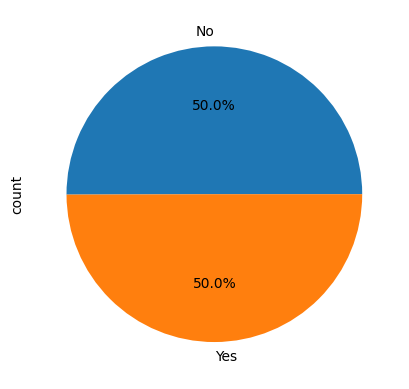

In [ ]:
df['Case Closed'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.show()

### **7.6 Analisis Senjata yang Digunakan**

In [ ]:
df['Weapon Used'].value_counts().head(10)

,count
Weapon Used,
Knife,5835
Explosives,5751
Blunt Object,5737
Poison,5728
Other,5676
Firearm,5643


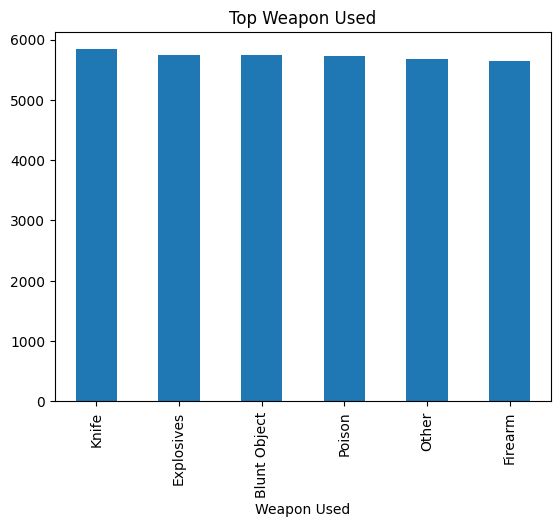

In [ ]:
df['Weapon Used'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Weapon Used")
plt.show()

### **7.7 Analisis Police Deployed**

In [ ]:
df['Police Deployed'].describe()

,Police Deployed
count,40160.000000
mean,10.006250
std,5.467951
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,19.000000


<Axes: xlabel='Police Deployed'>

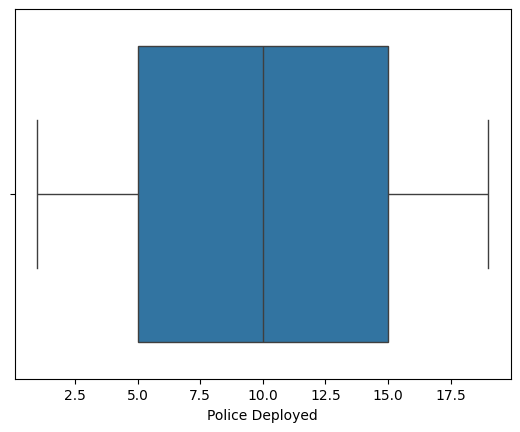

In [ ]:
sns.boxplot(
    x=df['Police Deployed']
)

In [ ]:
df['Victim Gender'].value_counts()
df['Victim Gender'].value_counts(normalize=True) * 100

,proportion
Victim Gender,
F,55.834163
M,33.378984
X,10.786853


In [ ]:
df['Case Closed'].value_counts()
df['Case Closed'].value_counts(normalize=True) * 100

,proportion
Case Closed,
No,50.044821
Yes,49.955179


## **8. Analisis Distribusi Kategori**

In [ ]:
gender_dist = df['Victim Gender'].value_counts(normalize=True) * 100
case_dist = df['Case Closed'].value_counts(normalize=True) * 100

print(gender_dist)
print(case_dist)

Victim Gender
F    55.834163
M    33.378984
X    10.786853
Name: proportion, dtype: float64
Case Closed
No     50.044821
Yes    49.955179
Name: proportion, dtype: float64


## **9. Deteksi Outlier**

In [ ]:
numerical_cols = ['Victim Age', 'Crime Code', 'Police Deployed', 'Report Number']

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Outlier Count
0,Victim Age,0
1,Crime Code,0
2,Police Deployed,0
3,Report Number,0


## **10. Data Cleaning**

In [ ]:
df.to_csv(
    'crime_dataset_clean.csv',
    index=False
)

## **11. Data Transformation**

In [ ]:
crime = df.copy()

## **12. Transformasi Data Tanggal**

In [ ]:
crime['Date Reported'] = pd.to_datetime(
    crime['Date Reported'],
    format='mixed',
    errors='coerce'
)

crime['Date of Occurrence'] = pd.to_datetime(
    crime['Date of Occurrence'],
    format='mixed',
    errors='coerce'
)

crime['Date Case Closed'] = pd.to_datetime(
    crime['Date Case Closed'],
    format='mixed',
    errors='coerce'
)

In [ ]:
crime[['Date Reported',
       'Date of Occurrence',
       'Date Case Closed']].head()

,Date Reported,Date of Occurrence,Date Case Closed
0,2020-01-02 00:00:00,2020-01-01 00:00:00,NaT
1,2020-01-01 19:00:00,2020-01-01 01:00:00,NaT
2,2020-01-02 05:00:00,2020-01-01 02:00:00,NaT
3,2020-01-01 05:00:00,2020-01-01 03:00:00,2020-04-29 05:00:00
4,2020-01-01 21:00:00,2020-01-01 04:00:00,2020-08-01 21:00:00


In [ ]:
crime[['Date Reported',
       'Date of Occurrence',
       'Date Case Closed']].isnull().sum()

,0
Date Reported,0
Date of Occurrence,0
Date Case Closed,20098


## **13. Pembuatan Atribut Waktu**

In [ ]:
crime['Year'] = crime['Date Reported'].dt.year

crime['Month'] = crime['Date Reported'].dt.month

crime['Month Name'] = crime['Date Reported'].dt.month_name()

crime['Quarter'] = crime['Date Reported'].dt.quarter

crime['Day'] = crime['Date Reported'].dt.day

In [ ]:
holiday_map = {
    "2020-01-26":"Republic Day",
    "2021-01-26":"Republic Day",
    "2022-01-26":"Republic Day",
    "2023-01-26":"Republic Day",
    "2024-01-26":"Republic Day",

    "2020-08-15":"Independence Day",
    "2021-08-15":"Independence Day",
    "2022-08-15":"Independence Day",
    "2023-08-15":"Independence Day",
    "2024-08-15":"Independence Day",

    "2020-10-02":"Gandhi Jayanti",
    "2021-10-02":"Gandhi Jayanti",
    "2022-10-02":"Gandhi Jayanti",
    "2023-10-02":"Gandhi Jayanti",
    "2024-10-02":"Gandhi Jayanti"
}

crime["Holiday Type"] = (
    crime["Date Reported"]
    .dt.strftime("%Y-%m-%d")
    .map(holiday_map)
    .fillna("Hari Biasa")
)

## **14. Penanganan Missing Value Weapon Used**

In [ ]:
crime['Weapon Used'] = crime['Weapon Used'].fillna(
    'Unknown')

## **15. Perhitungan Resolution Days**

In [ ]:
crime['Resolution Days'] = (
crime['Date Case Closed']
    - crime['Date Reported']
).dt.days

## **16. Simulasi Incremental Loading**

In [ ]:
batch1 = crime[
    crime['Date Reported'] < '2022-01-01'
]

In [ ]:
batch2 = crime[
    (crime['Date Reported'] >= '2022-01-01')
    &
    (crime['Date Reported'] < '2023-01-01')
]

In [ ]:
batch3 = crime[
    crime['Date Reported'] >= '2023-01-01'
]

In [ ]:
print(batch1.shape)
print(batch2.shape)
print(batch3.shape)

(17513, 22)
(8759, 22)
(13888, 22)


In [ ]:
crime.to_csv(
    'crime_transformed.csv',
    index=False
)

In [ ]:
crime.columns

Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed', 'Year', 'Month',
       'Month Name', 'Quarter', 'Day', 'Resolution Days', 'Age Group',
       'Holiday Type'],
      dtype='object')

In [ ]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Report Number       40160 non-null  int64         
 1   Date Reported       40160 non-null  datetime64[ns]
 2   Date of Occurrence  40160 non-null  datetime64[ns]
 3   Time of Occurrence  40160 non-null  object        
 4   City                40160 non-null  object        
 5   Crime Code          40160 non-null  int64         
 6   Crime Description   40160 non-null  object        
 7   Victim Age          40160 non-null  int64         
 8   Victim Gender       40160 non-null  object        
 9   Weapon Used         40160 non-null  object        
 10  Crime Domain        40160 non-null  object        
 11  Police Deployed     40160 non-null  int64         
 12  Case Closed         40160 non-null  object        
 13  Date Case Closed    20062 non-null  datetime64

## **17. Pembuatan Age Group**

In [ ]:
def age_group(age):

    if age <= 2:
        return "Bayi"

    elif age <= 5:
        return "Balita"

    elif age <= 12:
        return "Anak-anak"

    elif age <= 17:
        return "Remaja"

    elif age <= 25:
        return "Dewasa Awal"

    elif age <= 45:
        return "Dewasa"

    elif age <= 59:
        return "Pra Lansia"

    else:
        return "Lansia"

crime["Age Group"] = crime["Victim Age"].apply(age_group)

crime[["Victim Age","Age Group"]].head()

,Victim Age,Age Group
0,16,Remaja
1,37,Dewasa
2,48,Pra Lansia
3,49,Pra Lansia
4,30,Dewasa


## **18. Analisis Ketidakseimbangan Data**

In [ ]:
crime_domain_counts = crime['Crime Domain'].value_counts()
crime_domain_percent = crime['Crime Domain'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    "Count": crime_domain_counts,
    "Percentage": crime_domain_percent
})

imbalance_df

,Count,Percentage
Crime Domain,,
Other Crime,22948,57.141434
Violent Crime,11472,28.565737
Fire Accident,3825,9.524402
Traffic Fatality,1915,4.768426


In [ ]:
max_val = crime_domain_percent.max()
min_val = crime_domain_percent.min()

ratio = max_val / min_val

print("Max Percentage:", max_val)
print("Min Percentage:", min_val)
print("Ratio:", ratio)

Max Percentage: 57.14143426294821
Min Percentage: 4.768426294820717
Ratio: 11.983289817232377


## **19. Pembangunan Data Warehouse**

### **19.1 Dimensi Waktu (Dim Date)**

In [ ]:
dim_date = crime[
    [
        'Date Reported',
        'Year',
        'Quarter',
        'Month',
        'Month Name',
        'Day',
        'Holiday Type'
    ]
].drop_duplicates().reset_index(drop=True)

dim_date['date_id'] = range(1, len(dim_date)+1)

dim_date = dim_date[
    [
        'date_id',
        'Date Reported',
        'Year',
        'Quarter',
        'Month',
        'Month Name',
        'Day',
        'Holiday Type'
    ]
]

dim_date.head()

,date_id,Date Reported,Year,Quarter,Month,Month Name,Day,Holiday Type
0,1,2020-01-02 00:00:00,2020,1,1,January,2,Hari Biasa
1,2,2020-01-01 19:00:00,2020,1,1,January,1,Hari Biasa
2,3,2020-01-02 05:00:00,2020,1,1,January,2,Hari Biasa
3,4,2020-01-01 05:00:00,2020,1,1,January,1,Hari Biasa
4,5,2020-01-01 21:00:00,2020,1,1,January,1,Hari Biasa


### **19.2 Dimensi Kota (Dim City)**

In [ ]:
dim_city = crime[['City']].drop_duplicates().reset_index(drop=True)

dim_city['city_id'] = range(1, len(dim_city)+1)

dim_city = dim_city[
    ['city_id','City']
]

dim_city.head()

,city_id,City
0,1,Ahmedabad
1,2,Chennai
2,3,Ludhiana
3,4,Pune
4,5,Delhi


### **19.3 Dimensi Kejahatan (Dim Crime)**

In [ ]:
dim_crime = crime[
    [
        'Crime Description',
        'Crime Domain'
    ]
].drop_duplicates().reset_index(drop=True)

dim_crime['crime_id'] = range(
    1,
    len(dim_crime)+1
)

dim_crime = dim_crime[
    [
        'crime_id',
        'Crime Description',
        'Crime Domain'
    ]
]
dim_crime.head()

,crime_id,Crime Description,Crime Domain
0,1,IDENTITY THEFT,Violent Crime
1,2,HOMICIDE,Other Crime
2,3,KIDNAPPING,Other Crime
3,4,BURGLARY,Other Crime
4,5,VANDALISM,Other Crime


### **19.4 Dimensi Korban (Dim Victim)**

In [ ]:
dim_victim = crime[
    ['Victim Gender',
     'Age Group']
].drop_duplicates().reset_index(drop=True)

dim_victim['victim_id'] = range(
    1,
    len(dim_victim)+1
)

dim_victim = dim_victim[
    ['victim_id',
     'Victim Gender',
     'Age Group']
]

dim_victim.head()

,victim_id,Victim Gender,Age Group
0,1,M,Remaja
1,2,M,Dewasa
2,3,F,Pra Lansia
3,4,F,Dewasa
4,5,F,Lansia


### **19.5 Dimensi Senjata (Dim Weapon)**

In [ ]:
dim_weapon = crime[
    ['Weapon Used']
].drop_duplicates().reset_index(drop=True)

dim_weapon['weapon_id'] = range(
    1,
    len(dim_weapon)+1
)

dim_weapon = dim_weapon[
    ['weapon_id',
     'Weapon Used']
]

dim_weapon.head()

,weapon_id,Weapon Used
0,1,Blunt Object
1,2,Poison
2,3,Firearm
3,4,Other
4,5,Knife


In [ ]:
print("dim_date :", dim_date.shape)
print("dim_city :", dim_city.shape)
print("dim_crime :", dim_crime.shape)
print("dim_victim :", dim_victim.shape)
print("dim_weapon :", dim_weapon.shape)

dim_date : (25546, 8)
dim_city : (29, 2)
dim_crime : (21, 3)
dim_victim : (18, 3)
dim_weapon : (7, 2)


In [ ]:
crime['Crime Description'].nunique()

21

In [ ]:
crime['Crime Domain'].nunique()

4

## **20. Pembuatan Fact Table**

In [ ]:
fact_crime = crime.copy()

fact_crime = fact_crime.merge(
    dim_date,
    on=[
        'Date Reported',
        'Year',
        'Quarter',
        'Month',
        'Month Name',
        'Day'
    ],
    how='left'
)

print(fact_crime.columns)

Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed', 'Year', 'Month',
       'Month Name', 'Quarter', 'Day', 'Resolution Days', 'Age Group',
       'Holiday Type_x', 'date_id', 'Holiday Type_y'],
      dtype='object')


In [ ]:
fact_crime = fact_crime.merge(
    dim_city,
    on='City',
    how='left'
)

In [ ]:
fact_crime = fact_crime.merge(
    dim_crime,
    on=[
        'Crime Description',
        'Crime Domain'
    ],
    how='left'
)

In [ ]:
fact_crime = fact_crime.merge(
    dim_victim,
    on=[
        'Victim Gender',
        'Age Group'
    ],
    how='left'
)

In [ ]:
fact_crime = fact_crime.merge(
    dim_weapon,
    on='Weapon Used',
    how='left'
)

## **21. Pembuatan Measure Crime Count**

In [ ]:
fact_crime['crime_count'] = 1

In [ ]:
fact_crime.columns.tolist()

['Report Number',
 'Date Reported',
 'Date of Occurrence',
 'Time of Occurrence',
 'City',
 'Crime Code',
 'Crime Description',
 'Victim Age',
 'Victim Gender',
 'Weapon Used',
 'Crime Domain',
 'Police Deployed',
 'Case Closed',
 'Date Case Closed',
 'Year',
 'Month',
 'Month Name',
 'Quarter',
 'Day',
 'Resolution Days',
 'Age Group',
 'Holiday Type_x',
 'date_id',
 'Holiday Type_y',
 'city_id',
 'crime_id',
 'victim_id',
 'weapon_id',
 'crime_count']

## **22. Validasi Fact Table**

In [ ]:
missing = [
    'report_number',
    'date_id',
    'city_id',
    'crime_id',
    'victim_id',
    'weapon_id',
    'police_deployed',
    'resolution_days',
    'crime_count'
]

for col in missing:
    print(col, col in fact_crime.columns)

report_number False
date_id True
city_id True
crime_id True
victim_id True
weapon_id True
police_deployed False
resolution_days False
crime_count True


In [ ]:
'crime_count' in fact_crime.columns

True

In [ ]:
fact_crime['crime_count'] = 1

In [ ]:
fact_crime = fact_crime[[
    'Report Number',
    'date_id',
    'city_id',
    'crime_id',
    'victim_id',
    'weapon_id',
    'Police Deployed',
    'Resolution Days',
    'crime_count'
]]

fact_crime.shape

(40160, 9)

In [ ]:
fact_crime.columns

Index(['Report Number', 'date_id', 'city_id', 'crime_id', 'victim_id',
       'weapon_id', 'Police Deployed', 'Resolution Days', 'crime_count'],
      dtype='object')

In [ ]:
fact_crime.head()

,Report Number,date_id,city_id,crime_id,victim_id,weapon_id,Police Deployed,Resolution Days,crime_count
0,1,1,1,1,1,1,13,NaN,1
1,2,2,2,2,2,2,9,NaN,1
2,3,3,3,3,3,1,15,NaN,1
3,4,4,4,4,3,3,1,119.0,1
4,5,5,4,5,4,4,18,213.0,1


In [ ]:
fact_crime.columns.tolist()

['Report Number',
 'date_id',
 'city_id',
 'crime_id',
 'victim_id',
 'weapon_id',
 'Police Deployed',
 'Resolution Days',
 'crime_count']

In [ ]:
dim_date.head()

,date_id,Date Reported,Year,Quarter,Month,Month Name,Day,Holiday Type
0,1,2020-01-02 00:00:00,2020,1,1,January,2,Hari Biasa
1,2,2020-01-01 19:00:00,2020,1,1,January,1,Hari Biasa
2,3,2020-01-02 05:00:00,2020,1,1,January,2,Hari Biasa
3,4,2020-01-01 05:00:00,2020,1,1,January,1,Hari Biasa
4,5,2020-01-01 21:00:00,2020,1,1,January,1,Hari Biasa


In [ ]:
dim_city.head()

,city_id,City
0,1,Ahmedabad
1,2,Chennai
2,3,Ludhiana
3,4,Pune
4,5,Delhi


In [ ]:
dim_crime.head()

,crime_id,Crime Description,Crime Domain
0,1,IDENTITY THEFT,Violent Crime
1,2,HOMICIDE,Other Crime
2,3,KIDNAPPING,Other Crime
3,4,BURGLARY,Other Crime
4,5,VANDALISM,Other Crime


In [ ]:
dim_victim.head()

,victim_id,Victim Gender,Age Group
0,1,M,Remaja
1,2,M,Dewasa
2,3,F,Pra Lansia
3,4,F,Dewasa
4,5,F,Lansia


In [ ]:
dim_weapon.head()

,weapon_id,Weapon Used
0,1,Blunt Object
1,2,Poison
2,3,Firearm
3,4,Other
4,5,Knife


In [ ]:
fact_crime.head()

,Report Number,date_id,city_id,crime_id,victim_id,weapon_id,Police Deployed,Resolution Days,crime_count
0,1,1,1,1,1,1,13,NaN,1
1,2,2,2,2,2,2,9,NaN,1
2,3,3,3,3,3,1,15,NaN,1
3,4,4,4,4,3,3,1,119.0,1
4,5,5,4,5,4,4,18,213.0,1


In [ ]:
print("dim_date :", dim_date.shape)
print("dim_city :", dim_city.shape)
print("dim_crime :", dim_crime.shape)
print("dim_victim :", dim_victim.shape)
print("dim_weapon :", dim_weapon.shape)
print("fact_crime :", fact_crime.shape)
fact_crime.info()

dim_date : (25546, 8)
dim_city : (29, 2)
dim_crime : (21, 3)
dim_victim : (18, 3)
dim_weapon : (7, 2)
fact_crime : (40160, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Report Number    40160 non-null  int64  
 1   date_id          40160 non-null  int64  
 2   city_id          40160 non-null  int64  
 3   crime_id         40160 non-null  int64  
 4   victim_id        40160 non-null  int64  
 5   weapon_id        40160 non-null  int64  
 6   Police Deployed  40160 non-null  int64  
 7   Resolution Days  20062 non-null  float64
 8   crime_count      40160 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 2.8 MB


## **23. Export Hasil ETL**

In [ ]:
dim_date.to_csv('dim_date.csv', index=False)

dim_city.to_csv('dim_city.csv', index=False)

dim_crime.to_csv('dim_crime.csv', index=False)

dim_victim.to_csv('dim_victim.csv', index=False)

dim_weapon.to_csv('dim_weapon.csv', index=False)

fact_crime.to_csv('fact_crime.csv', index=False)

In [ ]:
import os

os.listdir()

['.config',
 'dim_date.csv',
 'fact_crime.csv',
 'crime_dataset_clean.csv',
 'fact_crime_fix2.csv',
 'crime_transformed.csv',
 'dim_weapon.csv',
 'drive',
 'dim_crime.csv',
 'fact_crime_fix3.csv',
 'dim_victim.csv',
 'dim_city.csv',
 'sample_data']

In [ ]:
dim_city.head()
dim_city.columns
dim_city.isnull().sum()

,0
city_id,0
City,0


In [ ]:
fact_crime[['date_id','city_id','crime_id','victim_id','weapon_id']].head()

,date_id,city_id,crime_id,victim_id,weapon_id
0,1,1,1,1,1
1,2,2,2,2,2
2,3,3,3,3,1
3,4,4,4,3,3
4,5,4,5,4,4


In [ ]:
fact_crime.to_csv('fact_crime_fix2.csv', index=False)

In [ ]:
fact_crime.shape
fact_crime.head()
fact_crime.columns
fact_crime.isnull().sum()

,0
Report Number,0
date_id,0
city_id,0
crime_id,0
victim_id,0
weapon_id,0
Police Deployed,0
Resolution Days,20098
crime_count,0


In [ ]:
fact_crime['Report Number'].duplicated().sum()

np.int64(0)

In [ ]:
fact_crime.columns = fact_crime.columns.str.strip()

fact_crime = fact_crime.applymap(
    lambda x: x.strip() if isinstance(x, str) else x
)

/tmp/ipykernel_5547/3818569424.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  fact_crime = fact_crime.applymap(


In [ ]:
fact_crime = fact_crime.rename(columns={
    'Report Number': 'report_number',
    'Police Deployed': 'police_deployed',
    'Resolution Days': 'resolution_days'
})

In [ ]:
fact_crime.columns.tolist()

['report_number',
 'date_id',
 'city_id',
 'crime_id',
 'victim_id',
 'weapon_id',
 'police_deployed',
 'resolution_days',
 'crime_count']

In [ ]:
fact_crime['resolution_days'] = fact_crime['resolution_days'].fillna(0)

In [ ]:
fact_crime['resolution_days'].isnull().sum()

np.int64(0)

In [ ]:
fact_crime = fact_crime.astype({
    'date_id': int,
    'city_id': int,
    'crime_id': int,
    'victim_id': int,
    'weapon_id': int,
    'police_deployed': int,
    'resolution_days': int,
    'crime_count': int
})

In [ ]:
fact_crime['resolution_days'].isnull().sum()

np.int64(0)

In [ ]:
fact_crime['resolution_days'] = fact_crime['resolution_days'].fillna(0)

In [ ]:
fact_crime.to_csv('fact_crime_fix3.csv', index=False)

In [ ]:
dim_date.head()

,date_id,Date Reported,Year,Quarter,Month,Month Name,Day,Holiday Type
0,1,2020-01-02 00:00:00,2020,1,1,January,2,Hari Biasa
1,2,2020-01-01 19:00:00,2020,1,1,January,1,Hari Biasa
2,3,2020-01-02 05:00:00,2020,1,1,January,2,Hari Biasa
3,4,2020-01-01 05:00:00,2020,1,1,January,1,Hari Biasa
4,5,2020-01-01 21:00:00,2020,1,1,January,1,Hari Biasa


In [ ]:
dim_date.to_csv(
    'dim_date2.csv',
    index=False
)

In [ ]:
fact_crime.columns.tolist()

['report_number',
 'date_id',
 'city_id',
 'crime_id',
 'victim_id',
 'weapon_id',
 'police_deployed',
 'resolution_days',
 'crime_count']